In [82]:
from pathlib import Path 
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import random
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf
from tensorflow.keras import layers, Model
import os
from tensorflow.keras.utils import to_categorical

In [83]:
# ===============================
# 0. Reproducibilidad global
# ===============================

SEED = 42

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# TensorFlow
tf.random.set_seed(SEED)

# Opcional: determinismo en GPU (más lento pero reproducible)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

print("Semilla global fijada en:", SEED)

Semilla global fijada en: 42


In [84]:
# ===============================
# 1. Cargar datos procesados
# ===============================

PROJECT_ROOT = Path().resolve().parent
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

X_train = np.load(PROCESSED_PATH / "train" / "X.npy")
y_train = np.load(PROCESSED_PATH / "train" / "y.npy")

X_val = np.load(PROCESSED_PATH / "val" / "X.npy")
y_val = np.load(PROCESSED_PATH / "val" / "y.npy")

# Normalización explícita para estabilidad numérica
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Pixel range:", X_train.min(), X_train.max())

Train shape: (6482, 128, 128, 3)
Validation shape: (1388, 128, 128, 3)
Pixel range: 0.0 0.003921569


In [85]:
# ===============================
# 2. Parámetros principales
# ===============================

input_shape = (128, 128, 3)
latent_dim = 64   # pequeño para empezar simple

### Encoder

In [86]:
# ===============================
# 3. Encoder
# ===============================

encoder_inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)  # 64x64
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)              # 32x32
x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)             # 16x16

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

# Media y log varianza
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

In [87]:
# ===============================
# 4. Sampling
# ===============================

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

In [88]:
# ===============================
# 5. Decoder
# ===============================

decoder_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(16*16*128, activation="relu")(decoder_inputs)
x = layers.Reshape((16,16,128))(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)  # 32x32
x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)   # 64x64
x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)   # 128x128

decoder_outputs = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

decoder = Model(decoder_inputs, decoder_outputs, name="decoder")

In [89]:
# ===============================
# 6-7. Modelo VAE personalizado (Keras 3 correcto)
# ===============================
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, beta=1.0):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        x = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(x - reconstruction), axis=(1,2,3))
            )

            kl_loss = tf.reduce_mean(
                -0.5 * tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = data

        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)

        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=(1,2,3))
        )

        kl_loss = tf.reduce_mean(
            -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = recon_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [90]:
# ===============================
# 7. Instanciar VAE
# ===============================

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

vae = VAE(encoder, decoder, beta=0.001)  # beta pequeño evita colapso

vae.compile(optimizer=tf.keras.optimizers.Adam())

In [91]:
# ===============================
# 7.1 Forzar construcción del modelo
# ===============================

vae.build(input_shape=(None, 128, 128, 3))
vae.compile(optimizer=tf.keras.optimizers.Adam())

In [93]:
history = vae.fit(
    X_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val,)
)

Epoch 1/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 51s 250ms/step - kl_loss: 329.5260 - loss: 0.5709 - recon_loss: 0.2413 - val_kl_loss: 25.1470 - val_loss: 0.2658 - val_recon_loss: 0.2407
Epoch 2/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 51s 253ms/step - kl_loss: 16.8223 - loss: 0.2604 - recon_loss: 0.2436 - val_kl_loss: 15.6007 - val_loss: 0.2565 - val_recon_loss: 0.2409
Epoch 3/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 49s 242ms/step - kl_loss: 14.2053 - loss: 0.2569 - recon_loss: 0.2427 - val_kl_loss: 13.2260 - val_loss: 0.2537 - val_recon_loss: 0.2405
Epoch 4/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 55s 272ms/step - kl_loss: 13.3625 - loss: 0.2556 - recon_loss: 0.2422 - val_kl_loss: 12.1183 - val_loss: 0.2526 - val_recon_loss: 0.2405
Epoch 5/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 47s 232ms/step - kl_loss: 12.0109 - loss: 0.2538 - recon_loss: 0.2418 - val_kl_loss: 11.5018 - val_loss: 0.2510 - val_recon_loss: 0.2395
Epoch 6/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 50s 245ms/step - kl_loss: 12.5874 - loss: 0.2540 - recon_loss: 0.2414 - va

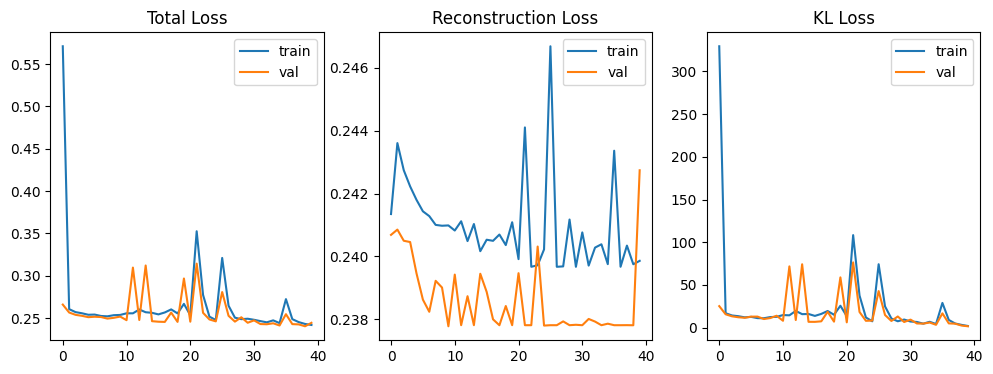

In [94]:
# ===============================
# 8.2 Curvas de entrenamiento
# ===============================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Total Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history["recon_loss"], label="train")
plt.plot(history.history["val_recon_loss"], label="val")
plt.title("Reconstruction Loss")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history["kl_loss"], label="train")
plt.plot(history.history["val_kl_loss"], label="val")
plt.title("KL Loss")
plt.legend()

plt.show()

In [95]:
# ===============================
# 8.3 Evaluación objetiva externa
# ===============================

from sklearn.metrics import mean_squared_error

recon_val = vae.predict(X_val)

mse_val = mean_squared_error(
    X_val.reshape(len(X_val), -1),
    recon_val.reshape(len(recon_val), -1)
)

print("Validation MSE:", mse_val)

44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step
Validation MSE: 4.837156211578986e-06


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


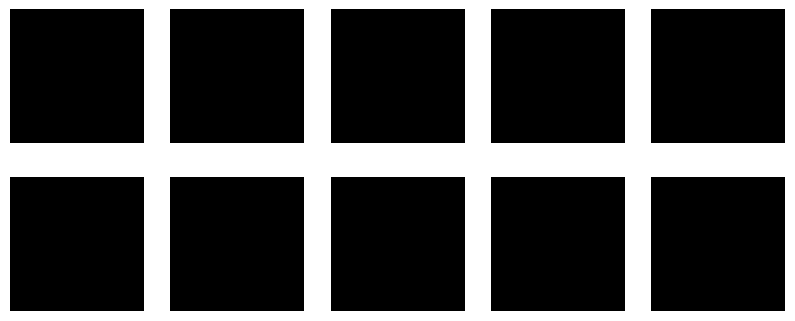

In [96]:
# ===============================
# 9. Visualizar reconstrucciones
# ===============================

recon = vae.predict(X_val[:5])

plt.figure(figsize=(10,4))

for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X_val[i])
    plt.axis("off")
    
    # Reconstruida
    plt.subplot(2,5,i+6)
    plt.imshow(recon[i])
    plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


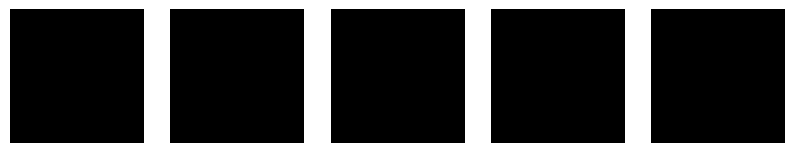

In [97]:
# ===============================
# 10. Generar caras nuevas (reproducible)
# ===============================

np.random.seed(SEED)
random_latent = np.random.normal(size=(5, latent_dim))

generated_images = decoder.predict(random_latent)

plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(generated_images[i])
    plt.axis("off")

plt.show()